## Spin density matrix measurement using $Z\rightarrow \tau\tau$ 

The spin density matrix (SDM) of $\tau\tau$ pairs produced in $Z$ boson decay can be expressed as 
$$\rho = \frac{1}{4} (I_4 + \sum_{i} (B_i^+ \sigma_i \otimes I_2 + B_i^- I_2 \otimes \sigma_i) + \sum_{i,j} C_{ij} \sigma_i \otimes \sigma_j),$$
where $I_4$ is the 4x4 identity matrix, $\sigma_i$ are the Pauli matrices, $B_i^+$, $B_i^-$ are the polarization vectors of each qubit, and $C_{ij}$ are the correlation matrix between the two qubits. 
The SDM can thus be determined by measuring the polarization vectors and correlation matrix elements.

$B_i^{\pm}$ and $C_{ij}$ can be extracted from the angular distributions of the decay products of the $\tau$ leptons:
$$
\frac{d\sigma}{dcos\theta_i^\pm} = \frac{1}{2} (1 + \kappa_{\pm} B_i^\pm cos\theta_i^\pm), 
$$
$$
\frac{d\sigma}{dcos\theta_i^+ dcos\theta_j^-} = -\frac{1}{2} ( 1 + \kappa_+\kappa_- C_{ij} cos\theta_i^+ cos\theta_j^-)log|cos\theta_i^+ cos\theta_j^-|,
$$
where $\theta_i^\pm$ are the angles of the decay products with respect to the spin quantization axis, and $\kappa_{\pm}$ are the analyzing powers determined by the decay channels.

To measure the SDM, we want to measure the distribution of $cos\theta_i^\pm$ and $cos\theta_i^+ cos\theta_j^-$.

## The $Z\rightarrow \tau\tau$ process at the LEP

A HadHad region which is dominated by several decay channels of $Z\rightarrow \tau\tau$ is selected. A view of cut flow for the HadHad region and the data/MC comparison is shown in the figures below. A good agreement between data and MC is observed.

<img src="./plots/cutflow_Ztautau_weighted.png" alt="cut_flow" width="50%">

<img src="./plots/control_plot_hadhad_ht.png" alt="data_mc_comparison" width="45%">


Take the $cos\theta_k^+$ distribution as an target distribution to be measured. We can view its distribution at the detector level and the particle level using the example dataset. From now on, "pipi" and "rhorho" represent the MC sample for each respective decay mode on the truth level.

In [ ]:
# Setup and load data
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import ROOT
import os
import sys

# setup project
notebook_dir = os.getcwd()
project_dir = os.path.dirname(notebook_dir)
sys.path = [project_dir, f'{project_dir}/processor/'] + sys.path

# Load the data
all_events = ak.from_parquet("dataset/filtered___raw.parquet")

# Specify your own RooUnfold lib here!!!
_ = ROOT.gSystem.Load("/home/cmo/softwares/RooUnfold/RooUnfold/build/libRooUnfold.so")


0

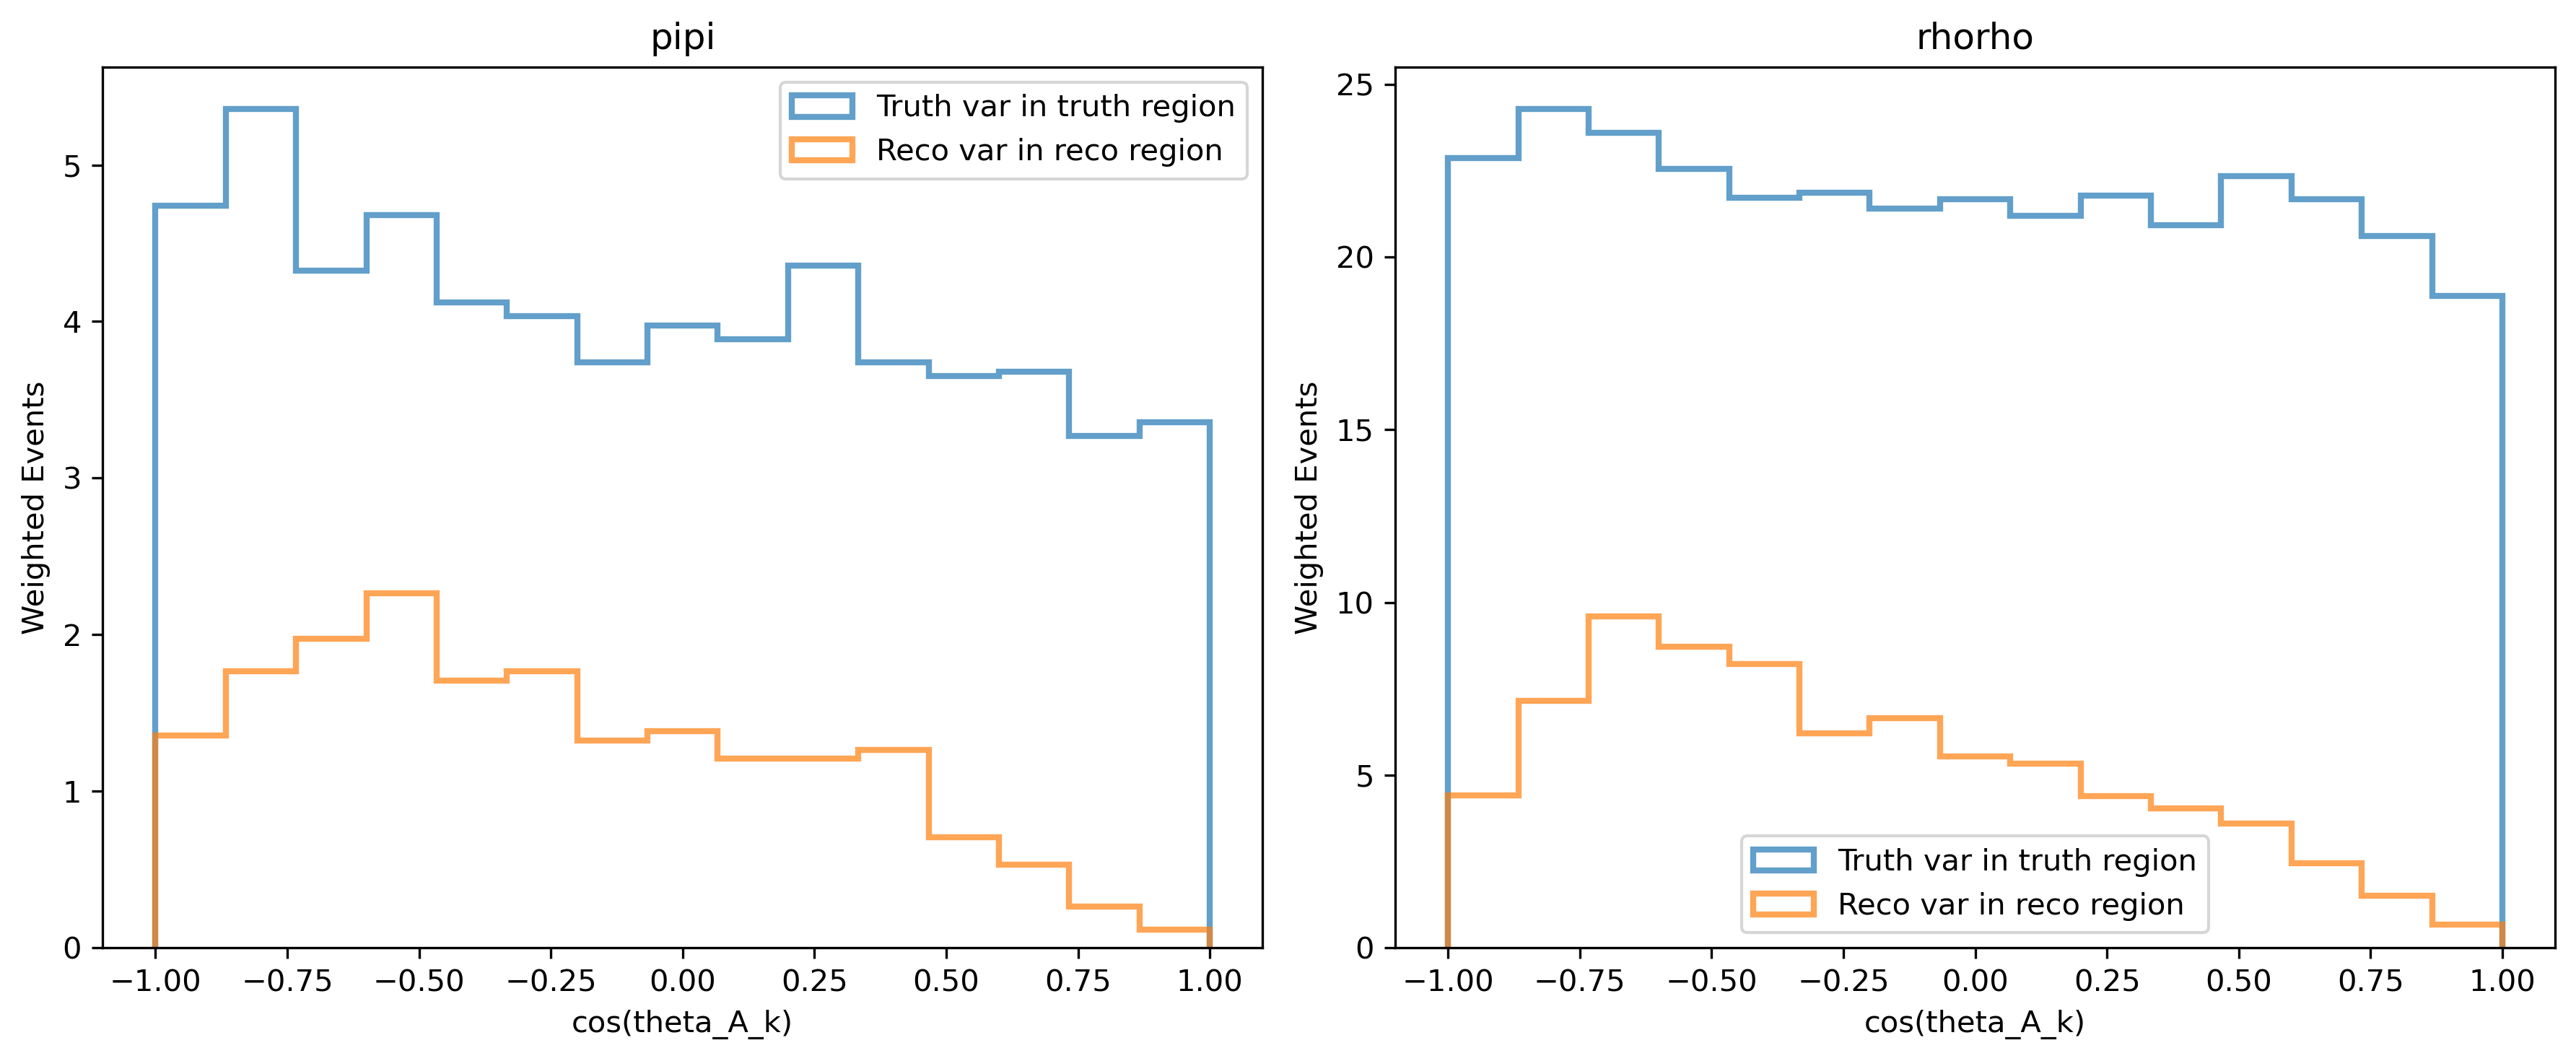

In [18]:

# Use tautau->pipi and tautau->rhorho events for the discussion
events_pipi = all_events[all_events.event_category==11]
events_rhorho = all_events[all_events.event_category==22]
# Compare the distribution of cos_theta_A_k in truth and reco level, both for pipi and rhorho
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

bins = np.linspace(-1, 1, 16)
for i, (events, title) in enumerate(zip([events_pipi, events_rhorho], ["pipi", "rhorho"])):
    ax = axes[i]
    weight = events.weight

    # Truth level
    mask_truth_region = events.truth_QI_region == 1
    ax.hist(events.truth_cos_theta_A_k[mask_truth_region], bins=bins, alpha=0.7, label="Truth var in truth region", weights=weight[mask_truth_region], histtype='step', linewidth=2)

    # Reco level
    mask_reco_region = (events.hadhad_cut) & (events.theta_cm > 0.6 * np.pi / 2)

    ax.hist(events.cos_theta_A_k[mask_reco_region], bins=bins, alpha=0.7, label="Reco var in reco region", weights=weight[mask_reco_region], histtype='step', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("cos(theta_A_k)")
    ax.set_ylabel("Weighted Events")
    ax.legend()

plt.tight_layout()
plt.show()


## Unfolding

The response matrices are built to describe the relationship between the truth observable in the truth region (blue histograms above) and the reconstructed observable in the HadHad region (orange histograms above). One matrix is built for **each signal sample (decay channel)** and **each observable**.

In [3]:
f_response = ROOT.TFile('dataset/response.root', 'READ')
response_pipi = f_response.Get("Ztautau_pipi_cos_theta_A_k")
response_rhorho = f_response.Get("Ztautau_rhorho_cos_theta_A_k")


In [4]:
# plot both pipi and rhorho in the same canvas, one row with two columns
c = ROOT.TCanvas("Response", "Response", 800, 400)
c.Divide(2, 1)
for i, response_details in enumerate([(response_pipi, "pipi"), (response_rhorho, "rhorho")]):
    response, name = response_details
    c.cd(i + 1)
    r = response.HresponseNoOverflow()
    r.SetTitle(name)
    r.SetStats(0)
    r.Draw("colz")
c.Draw()

To validate the performance of the response matrix, we will compare the following distributions dreived from **the same decay mode** using MC sample:
* Truth level distribution in the truth region
* Reco level distribution in the analysis region
* Unfolded distribution derived from reco distribution and response matrix

Unfolding the signals of example dataset


/tmp/ipykernel_28584/3633911093.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
Warning in <TFile::Append>: Replacing existing TH1: h_cos_theta_A_k_reco_pipi (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_cos_theta_A_k_reco_rhorho (Potential memory leak).


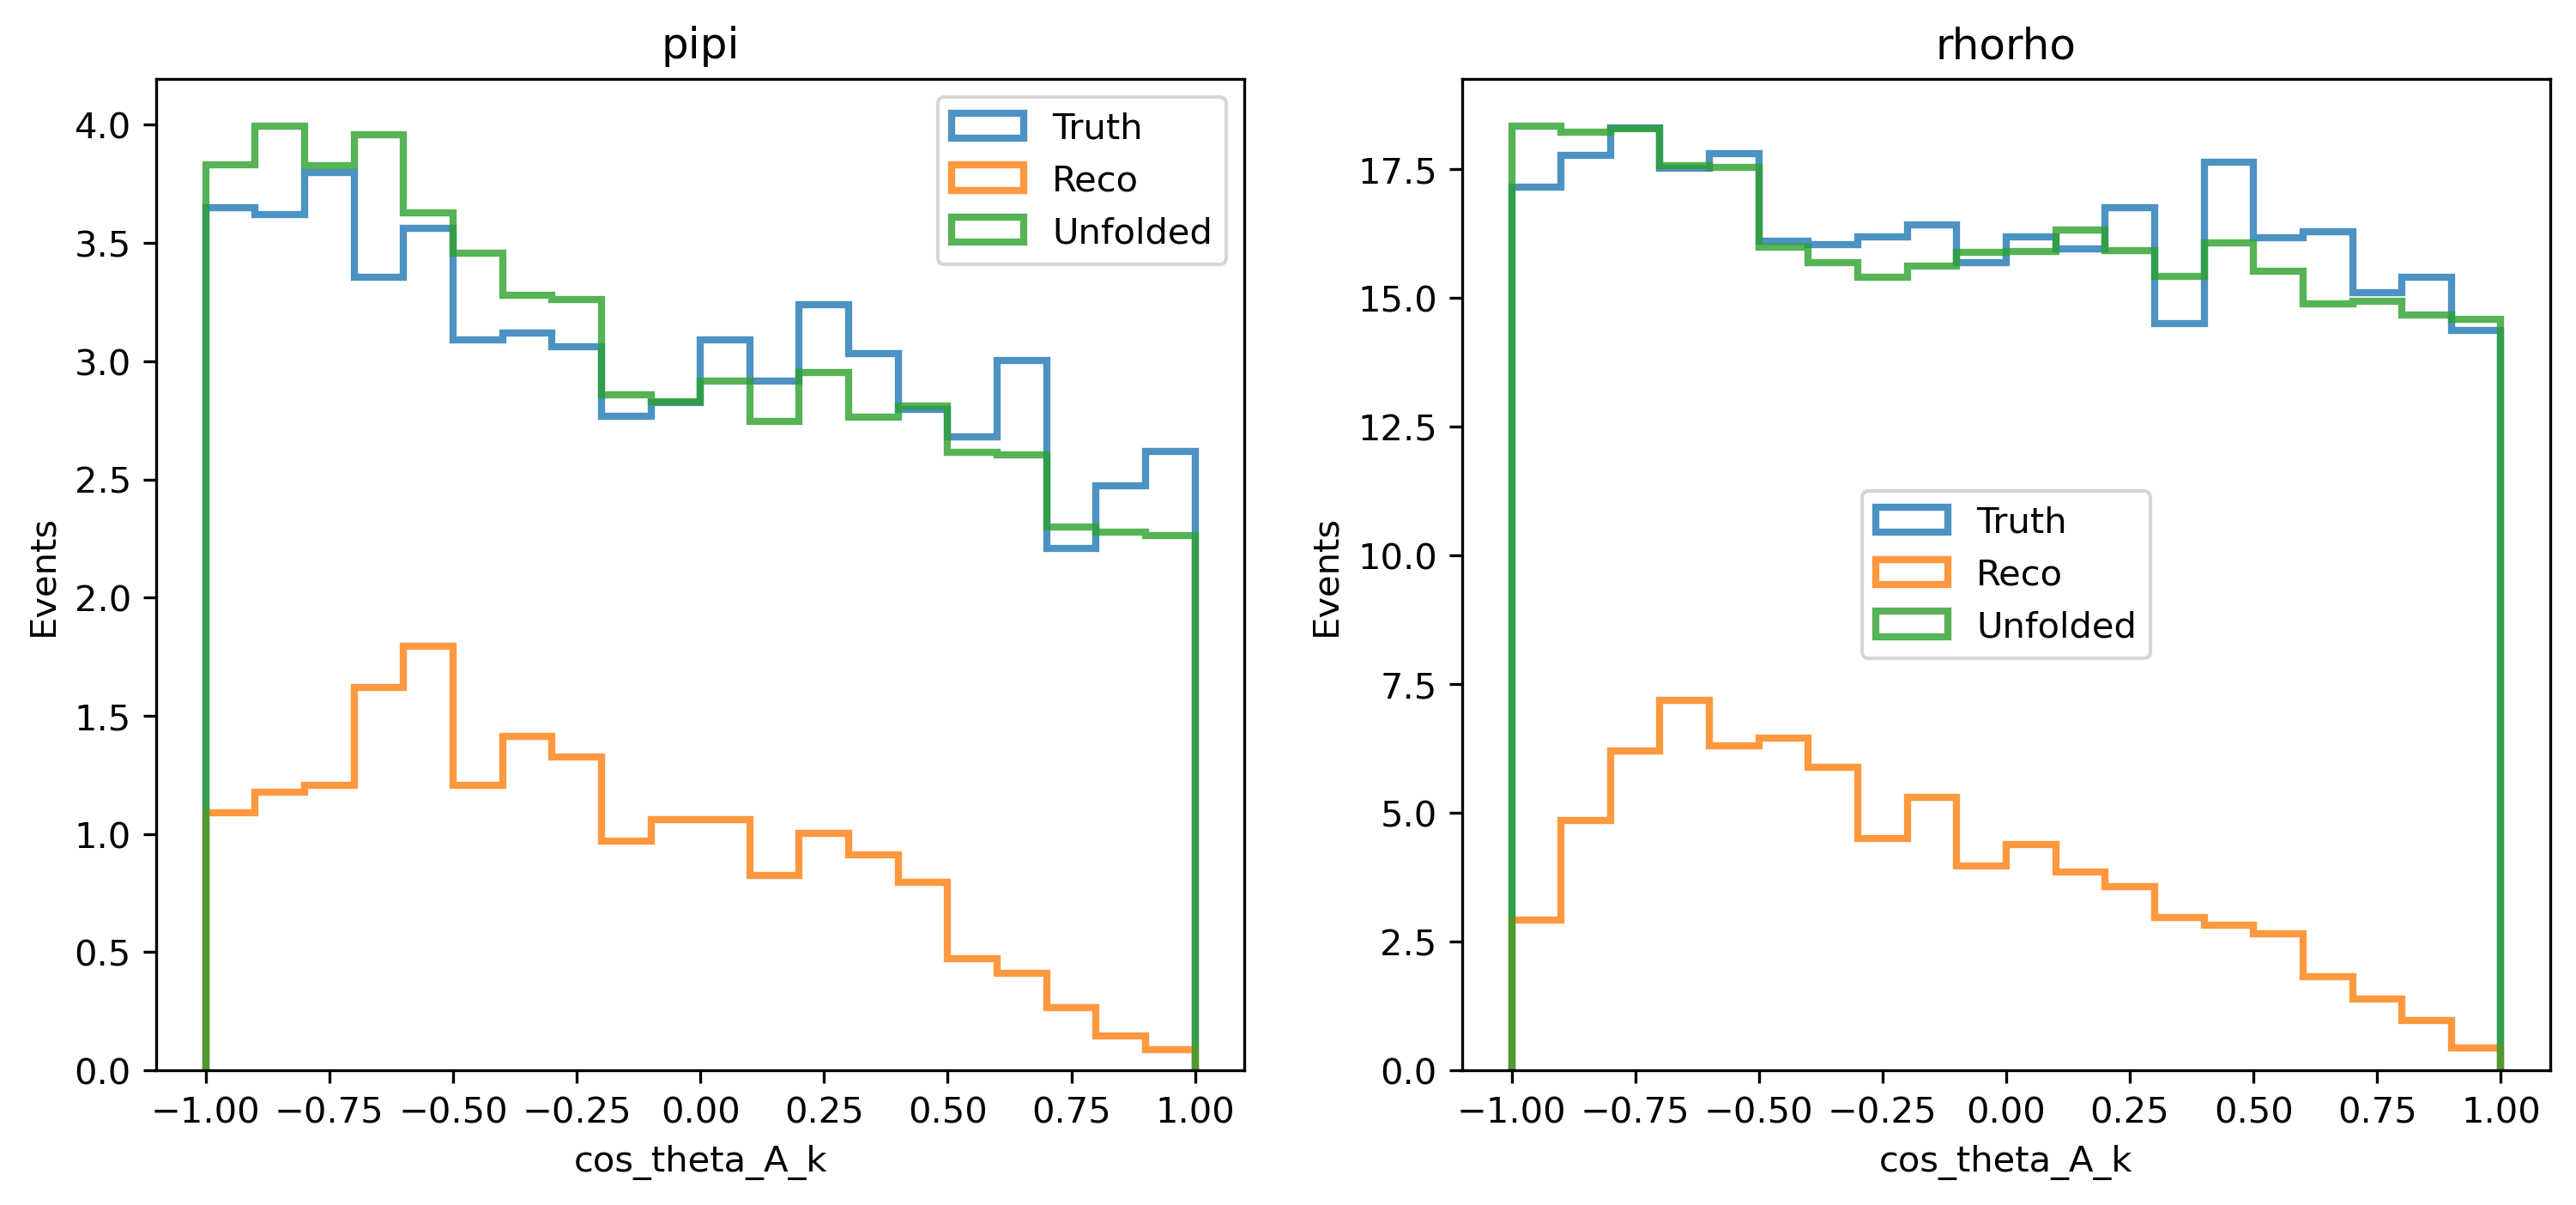

In [19]:
from QIProcessor import binning_variable
import quantum.unfold as unfold
print('Unfolding the signals of example dataset')

var_name = 'cos_theta_A_k'
num_bins = 20
bin_edges = np.linspace(-1, 1, num_bins + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
for i, (events, response, channel) in enumerate([
    (events_pipi, response_pipi, "pipi"),
    (events_rhorho, response_rhorho, "rhorho")
]):
    mask_truth_region = events.truth_QI_region == 1
    mask_reco_region = (events.hadhad_cut) & (events.theta_cm > 0.6 * np.pi / 2)
    weight = events['weight']

    h_truth_npy = np.histogram(events[f'truth_{var_name}'][mask_truth_region], bins=bin_edges, weights=weight[mask_truth_region])[0]

    binned_reco = binning_variable(ak.to_numpy(events[f'{var_name}'][mask_reco_region]), bin_edges)
    h_measure = unfold.build_TH1D(f"h_{var_name}_reco_{channel}", binned_reco, num_bins=num_bins, weight=weight[mask_reco_region])
    h_reco_npy = unfold.build_Hist_from_TH1D(h_measure, bin_edges=bin_edges)

    # unfold
    h_unfold = ROOT.RooUnfoldSvd(response, h_measure, 5).Hunfold(2)
    h_unfold_npy = unfold.build_Hist_from_TH1D(h_unfold, bin_edges=bin_edges)


    # plot the histograms
    ax = axes[i]
    bin_center = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.hist(bin_center, weights=h_truth_npy, bins=bin_edges, alpha=0.8, label="Truth", histtype="step", linewidth=2)
    ax.hist(bin_center, weights=h_reco_npy, bins=bin_edges, alpha=0.8, label="Reco", histtype="step", linewidth=2)
    ax.hist(bin_center, weights=h_unfold_npy, bins=bin_edges, alpha=0.8, label="Unfolded", histtype="step", linewidth=2)
    ax.set_xlabel(f"{var_name}")
    ax.set_ylabel("Events")
    ax.legend()
    ax.set_title(f"{channel}")

fig.show()

We have several potential methods to derive the 15 parameters (PoIs, 6 for polarizations and 9 for spin correlations). 

##### **1. Traditional Unfolding**

We treat a specific sample (e.g. pipi) as the signal, all the other samples, including $Z\rightarrow \tau\tau$ samples that do not decay into $\pi\pi$, as the background. We then unfold the pipi distribution using `ROOT.RooUnfoldSvd(response_pipi, h_data - h_background - h_non_pipi_ZtautauSample)`. The 15 PoIs are then derived by fitting the unfolded distribution.

Concerns:
* The shape of `h_non_pipi_ZtautauSample` is correlated with PoIs. We need to make strong assumption to treat  `h_data - h_background - h_non_pipi_ZtautauSample` as the reco-level distribution of pipi sample to unfold.
* Treating non_pipi_ZtautauSample as background is a loss of sensitivity.


##### **2. Forward Folding**

We parametrize the truth distribution of each signal sample as a function of the PoIs, i.e. `h_truth(channel, PoIs)`, then forward fold the truth distribution to reco-level, `h_reco(channel, PoIs) = response(channel).ForwardFold(h_truth(channel, PoIs))`. In this way, a template likelihood method using `h_data` and `h_reco` can be employed to derive the 15 PoIs: 
```
likelihood(PoIs) = P(h_data | sum([h_reco(channel, PoIs) for channel in channels]) ),
PoI = argmax likelihood(PoIs)
```
Concern:
* We may not be able to parameterize the truth distribution properly.


##### **3. Other Concern**

Are the 15 PoIs uncorrelated to each other? Also are the corresponding 15 distributions independent? Is it correct to build 15 1-D response matrix independently?